# Image segmentation using clustering

Credit: inspired by Frederik FRBJ :)

In this exercise, you will apply clustering methods to the good old Windows XP landscape to begin with, and then your own image of your choice. You will perform colour segmentation, assuming that pixels with a similar colour capture similar objects. Each pixel is a datapoint in three dimensions and each colour is a cluster.

In [6]:
from PIL import Image
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import DBSCAN

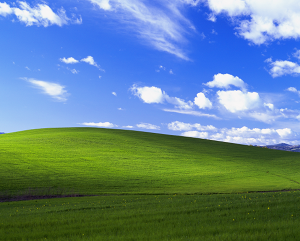

In [2]:
img = Image.open('images/xp_wallpaper_low_resolution.png')
img

We will treat each pixel as a datapoint with three features: red, blue and green values. Depending on your harware, feel free to choose between the high and low resolution version.
- high resolution: 1664 x 2496 pixels = 4153344 data points
 - low resolution:  300 x 241 pixels = 72300 data points

In [3]:
X_image = np.asarray(img)
X = X_image.reshape(-1, 3)
X.shape

(72300, 3)

## 1. $k$-means

We will start by applying $k$-means algorithm to the image.

1. Just by looking at the image (domain knowledge), what should the value of $k$ be? Aka, how many different colour groups are there? What do these colours represent?
2. Run a $k$-means algorithm with variant values for $k$. Use the elbow method to decide for optimal value of $k$. Is that the same value you estimated in the first step?
3. Display each data point as a colour representing the center of the corresponding cluster. Display the image with these simplified colours. Try with different values for $k$ and see how the image changes.
4. Use this clustering to only display the hill in average green, and the sky in average blue ($k$=2).
5. Now keep the hill the original value of pixels, and replace the sky with all white. You should get a result that resembles background removal.
6. Experiment with other images. Try some with not so simple colour palette. What about a rainbow where the colours flow into each other? What about a grey-scale image?

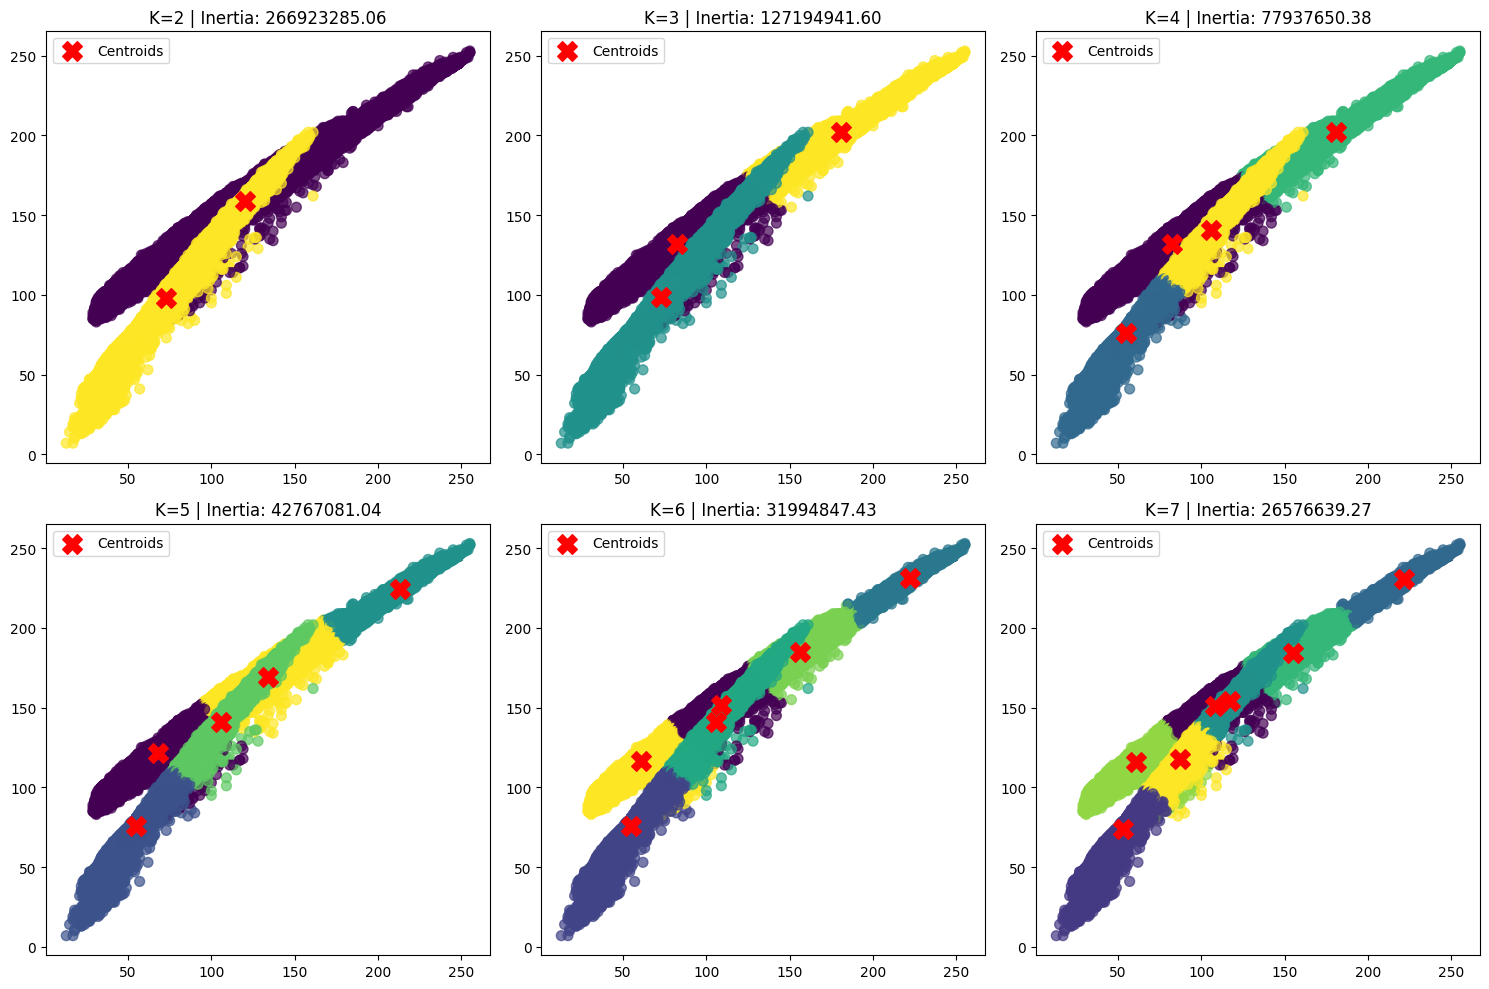

In [26]:
k_values = [2, 3, 4, 5, 6, 7]
inertias = []

plt.figure(figsize=(15, 10))

for i, k in enumerate(k_values):
    # k-means++ is the default in sklearn, but we'll be explicit
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init='auto', random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

    plt.subplot(2, 3, i+1)
    plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='viridis', s=50, alpha=0.7)
    plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                marker='X', s=200, c='red', label='Centroids')
    plt.title(f"K={k} | Inertia: {kmeans.inertia_:.2f}")
    plt.legend()

plt.tight_layout()
plt.show()

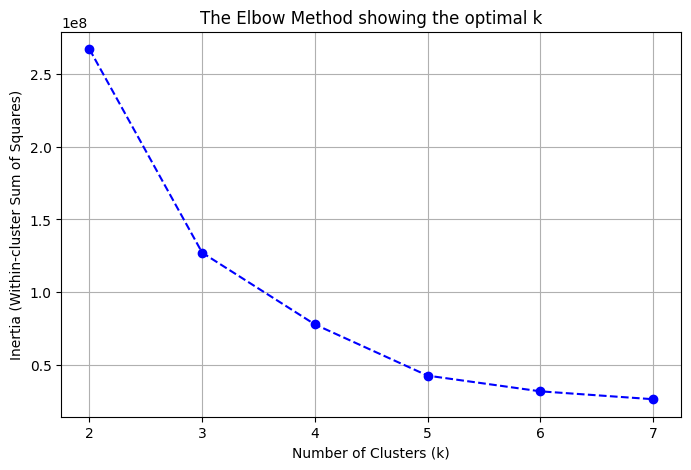

In [27]:
# elbow method plot
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o', linestyle='--', color='b')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-cluster Sum of Squares)')
plt.title('The Elbow Method showing the optimal k')
plt.xticks(k_values)
plt.grid(True)
plt.show()

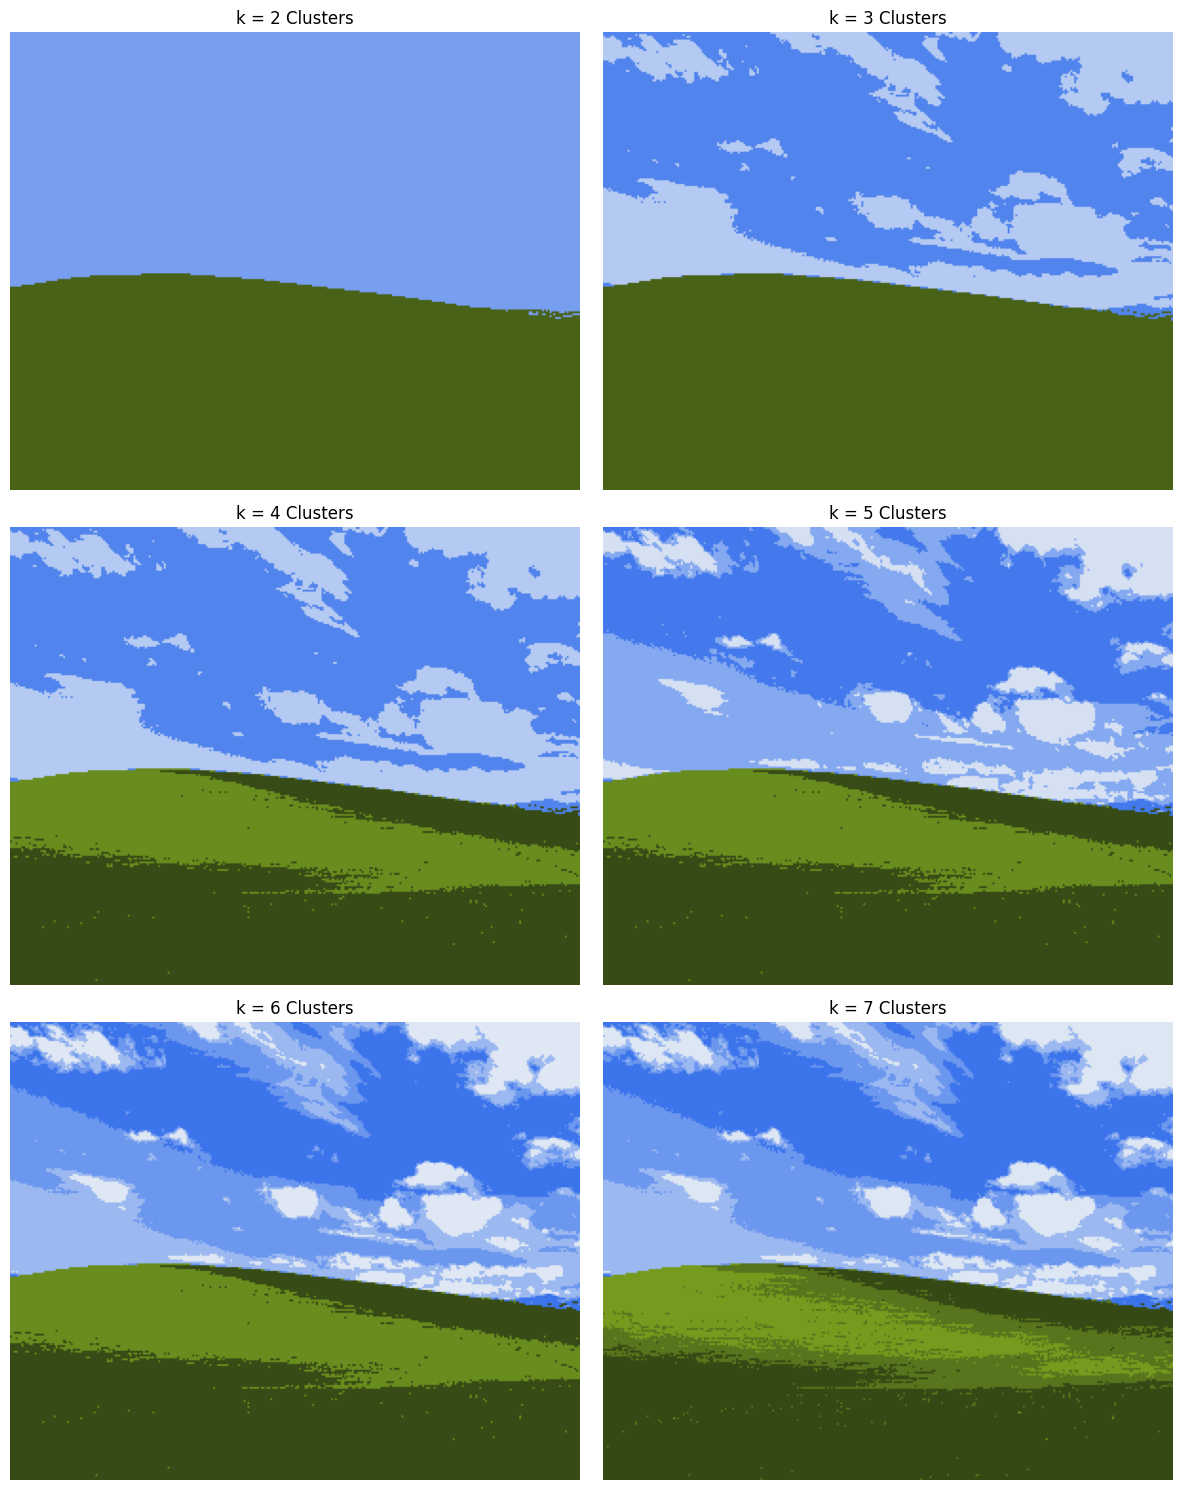

In [28]:
n_values = [2, 3, 4, 5, 6, 7]

# Create a figure with a 3x2 grid
fig, axes = plt.subplots(3, 2, figsize=(12, 15))
axes = axes.flatten()  # Flatten the 2D array of axes for easy indexing

for i, k in enumerate(n_values):
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    kmeans.fit(X)

    # Convert each pixel to its corresponding cluster center color
    segmented_data = kmeans.cluster_centers_[kmeans.labels_]

    # Reshape back to the original image dimensions
    segmented_img = segmented_data.reshape(X_image.shape)

    # Plot on the corresponding subplot
    axes[i].imshow(segmented_img.astype(np.uint8))
    axes[i].set_title(f'k = {k} Clusters')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [29]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X)

,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


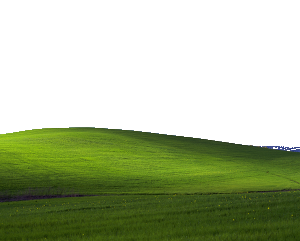

In [30]:
ground = X.copy()
for i in range(len(kmeans.labels_)):
    if kmeans.labels_[i] == 0:
        ground[i] = np.array([255, 255, 255])
ground = ground.reshape(X_image.shape)
Image.fromarray(ground.astype(np.uint8))

## 2. Agglomerative clustering

1. Try to do a similar colour analysis but this time using agglomerative clustering.
2. Print the dendogram. What should be the optimal number of clusters? Compare that number to $k$-means from before.

Note: since agglomerative clustering runs in $O(n^2)$, this might take a while (took my laptop 22 minutes)

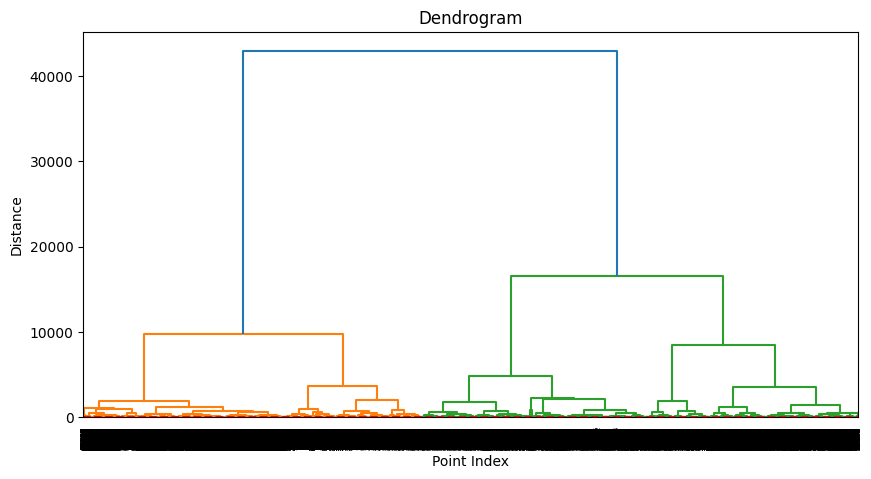

In [4]:
Z = linkage(X, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.axhline(y=25, color='r', linestyle='--') # The "Cut"
plt.title("Dendrogram")
plt.xlabel("Point Index")
plt.ylabel("Distance")
plt.show()

## 3. DBSCAN

1. Try to run DBSCAN on the image(s). Try different hyperparameters. How do they influece the result?
2. Use DBSCAN to idetify outliers.

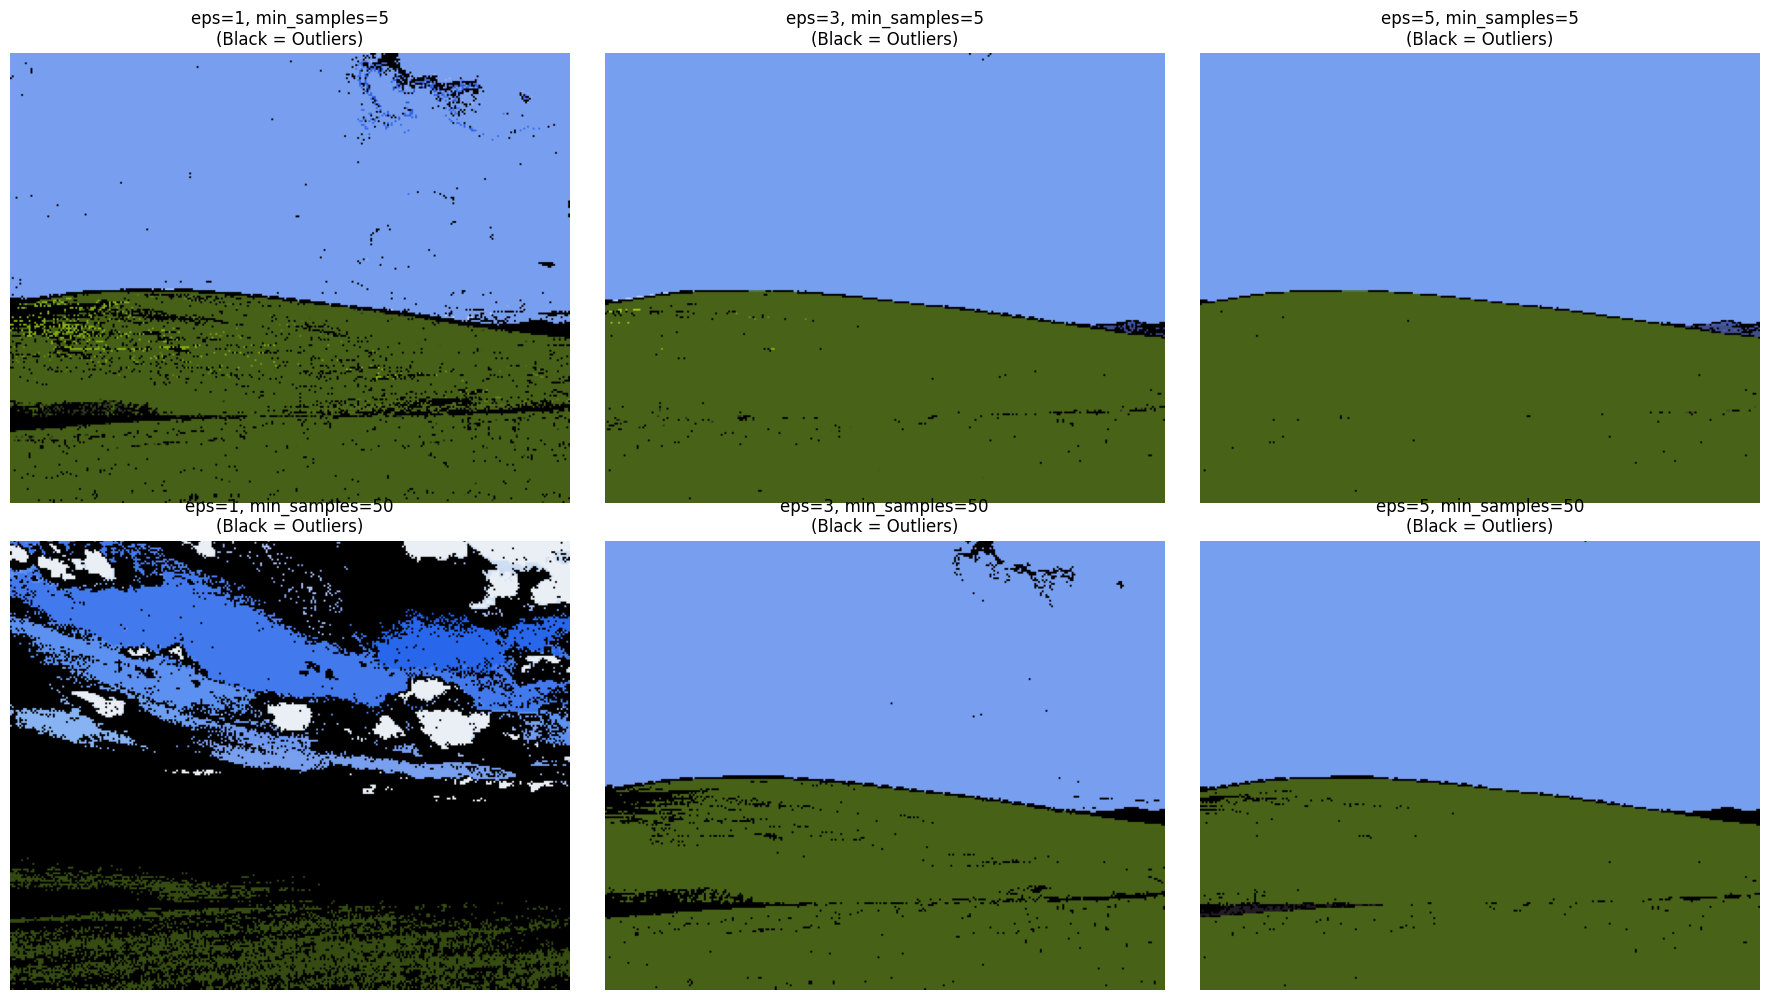

In [8]:
min_samples_values = [5, 50]
eps_values = [1, 3, 5]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

plot_idx = 0
for ms in min_samples_values:
    for e in eps_values:
        db = DBSCAN(eps=e, min_samples=ms)
        labels = db.fit_predict(X)

        # Create a blank image array for the result
        segmented_data = np.zeros_like(X)

        # Get unique clusters (excluding noise -1)
        unique_labels = set(labels)
        if -1 in unique_labels:
            unique_labels.remove(-1)

        # For each cluster, calculate the mean color and assign it
        # Outliers (label == -1) remain [0, 0, 0] (Black)
        for label in unique_labels:
            mask = (labels == label)
            mean_color = X[mask].mean(axis=0)
            segmented_data[mask] = mean_color

        # Reshape and plot
        segmented_img = segmented_data.reshape(X_image.shape)

        ax = axes[plot_idx]
        ax.imshow(segmented_img.astype(np.uint8))
        ax.set_title(f'eps={e}, min_samples={ms}\n(Black = Outliers)')
        ax.axis('off')

        plot_idx += 1

plt.tight_layout()
plt.show()

## 4. Overview

1. What algorithm is the best fit for such an image processing task? What makes it the best?
2. What are the considerations around hyperparameter tuning, running time and the expected output?
3. Give examples of tasks that each of the algorithms are good, and better fit than the others, and give reasons why.